In [2]:
%matplotlib inline

import numpy as np
from runOFDR import C0, run_experiment, show_experiment

# Front end only: the fiber, probe, disturbance and detection models are in the .py files.
# nonlinear/custom probes use the coherent template a(t-delay) * conj(a(t)).
# Wiener delay inversion is kept in getMatchedFilterPhase.py for static raw-field convolution only.

# Fiber geometry
total_length = 10.0
number_of_stretchers = 3
number_of_sections = number_of_stretchers + 1
stretcher_positions = np.linspace(total_length / number_of_sections, total_length * number_of_stretchers / number_of_sections, number_of_stretchers)
# stretcher_positions = np.array([1.8, 4.6, 7.9])                         # manual positions
# section_lengths_manual = np.array([1.8, 2.8, 3.3, 2.1]); stretcher_positions = np.cumsum(section_lengths_manual)[:-1]; total_length = np.sum(section_lengths_manual)

# Rayleigh scatterers
scatterers_per_meter = 2.0
min_scatterers_per_section = 20       # original code used 20; set 1 for a nearly exact density
center_distribution = 'grid'          # grid, uniform, gaussian, rayleigh
coefficient_distribution = 'gaussian' # uniform, gaussian, rayleigh
seed = 4

# Propagation
use_attenuation = False
attenuation_db_per_km = 0.2
phase_mode = 'quasistatic'             # quasistatic, dynamic
n_eff = 1.5
phase_index = 1.5                     # may differ from the group index n_eff
wavelength = 1550e-9

# Probe and acquisition
probe_type = 'linear_chirp'            # linear_chirp, nonlinear_chirp, custom
sample_rate = 1.0e6
duration = 0.020
sweep_rate = 0.25 * sample_rate * C0 / (2.0 * n_eff * total_length)
sweep_span = sweep_rate * duration
nonlinearity = 0.4                     # 0 gives a linear chirp with the same span

# Disturbance phase g(t): every later stretcher gets 10% more amplitude and frequency_spacing more Hz
phase_type = 'sinusoidal'              # sinusoidal, gaussian_burst, damped_ringdown, custom
phase_amplitude = 0.22
phase_frequency = 120.0
frequency_spacing = 130.0
burst_width = 0.003
decay_time = 0.005
custom_phase_max_frequency = 380.0    # update this after editing user_phase

# Detection
detection_method = 'auto'              # linear FFT for linear_chirp; matched filter otherwise
spatial_window_length = 0.12
matched_window_duration = 0.0008
phase_time_points = 121
profile_points = 801

# Edit these two functions, then choose custom above.
def user_probe(t, duration, sweep_span):
    x = t / duration
    return np.exp(2j * np.pi * sweep_span * duration * (0.5 * x**2 + 0.05 * x**4))

def user_phase(t, stretcher_index, amplitude, frequency):
    return amplitude * np.sin(2.0 * np.pi * frequency * t)

config = {
    'total_length': total_length, 'stretcher_positions': stretcher_positions,
    'scatterers_per_meter': scatterers_per_meter, 'min_scatterers_per_section': min_scatterers_per_section,
    'center_distribution': center_distribution,
    'coefficient_distribution': coefficient_distribution, 'seed': seed,
    'use_attenuation': use_attenuation, 'attenuation_db_per_km': attenuation_db_per_km,
    'phase_mode': phase_mode, 'n_eff': n_eff, 'phase_index': phase_index, 'wavelength': wavelength,
    'probe_type': probe_type, 'sample_rate': sample_rate, 'duration': duration,
    'sweep_rate': sweep_rate, 'sweep_span': sweep_span, 'nonlinearity': nonlinearity,
    'phase_type': phase_type, 'phase_amplitude': phase_amplitude,
    'phase_frequency': phase_frequency, 'frequency_spacing': frequency_spacing,
    'burst_width': burst_width, 'decay_time': decay_time,
    'custom_phase_max_frequency': custom_phase_max_frequency,
    'detection_method': detection_method, 'spatial_window_length': spatial_window_length,
    'matched_window_duration': matched_window_duration, 'phase_time_points': phase_time_points,
    'profile_points': profile_points, 'custom_probe_function': user_probe,
    'custom_phase_function': user_phase,
}


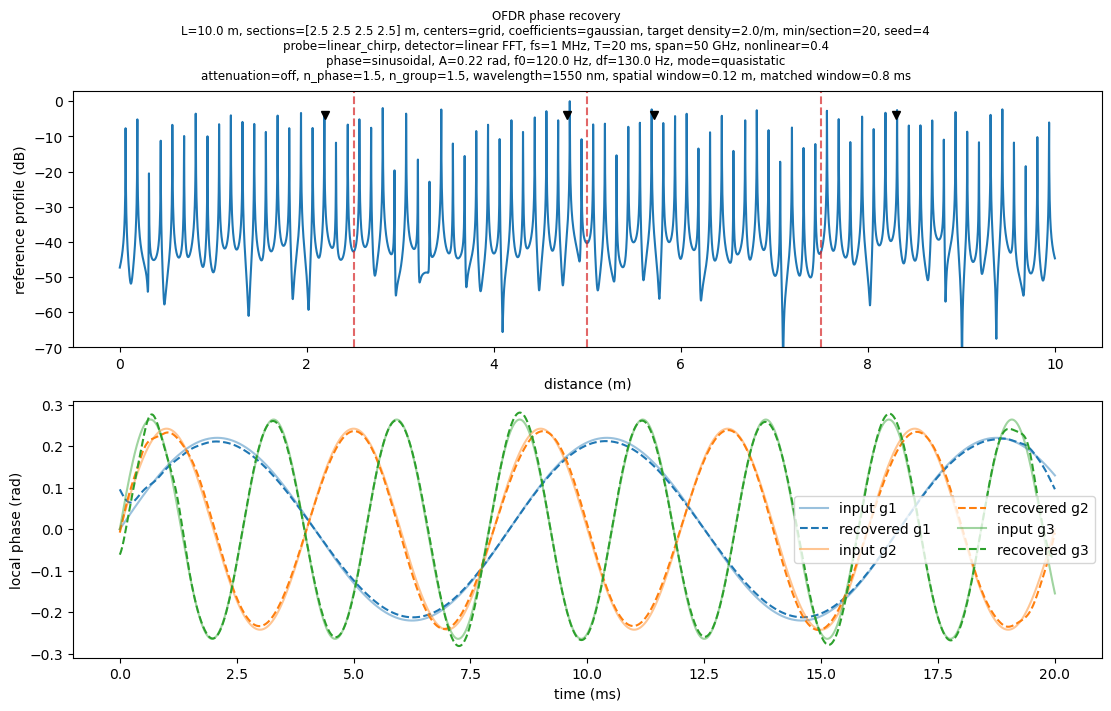

section lengths (m): [2.5 2.5 2.5 2.5]
scatterers per section: [20 20 20 20]
stretcher positions (m): [2.5 5.  7.5]
selected channel centers (m): [2.192 4.777 5.715 8.301]
g(t) reconstruction RMSE (rad): [0.00915 0.00878 0.0141 ]


In [3]:
result = run_experiment(config)
show_experiment(result, config)

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def run_from_widgets(total_length, number_of_stretchers, section_lengths_text,
                     scatterers_per_meter, min_scatterers_per_section, center_distribution, coefficient_distribution,
                     use_attenuation, attenuation_db_per_km, phase_mode, probe_type,
                     phase_type, phase_amplitude, phase_frequency, frequency_spacing,
                     nonlinearity, detection_method, sample_rate, duration, seed):
    if section_lengths_text.strip():
        section_lengths = np.fromstring(section_lengths_text, sep=',')
        total_length = np.sum(section_lengths)
        stretcher_positions = np.cumsum(section_lengths)[:-1]
    else:
        stretcher_positions = np.linspace(total_length / (number_of_stretchers + 1), total_length * number_of_stretchers / (number_of_stretchers + 1), number_of_stretchers)

    widget_config = config.copy()
    widget_config.update({
        'total_length': total_length, 'stretcher_positions': stretcher_positions,
        'scatterers_per_meter': scatterers_per_meter, 'min_scatterers_per_section': min_scatterers_per_section,
        'center_distribution': center_distribution,
        'coefficient_distribution': coefficient_distribution, 'use_attenuation': use_attenuation,
        'attenuation_db_per_km': attenuation_db_per_km, 'phase_mode': phase_mode,
        'probe_type': probe_type, 'phase_type': phase_type, 'phase_amplitude': phase_amplitude,
        'phase_frequency': phase_frequency, 'frequency_spacing': frequency_spacing,
        'nonlinearity': nonlinearity, 'detection_method': detection_method,
        'sample_rate': sample_rate, 'duration': duration, 'seed': seed,
    })
    widget_config['sweep_rate'] = 0.25 * sample_rate * C0 / (2.0 * widget_config['n_eff'] * total_length)
    widget_config['sweep_span'] = widget_config['sweep_rate'] * duration
    widget_result = run_experiment(widget_config)
    show_experiment(widget_result, widget_config)

initial_section_lengths = np.diff(np.r_[0.0, config['stretcher_positions'], config['total_length']])
initial_sections_text = '' if np.allclose(initial_section_lengths, initial_section_lengths[0]) else ','.join(f'{length:g}' for length in initial_section_lengths)
controls = {
    'total_length': widgets.IntSlider(value=int(config['total_length']), min=10, max=1000, step=10, description='fiber (m)', continuous_update=False),
    'number_of_stretchers': widgets.IntSlider(value=len(config['stretcher_positions']), min=1, max=5, description='stretchers', continuous_update=False),
    'section_lengths_text': widgets.Text(value=initial_sections_text, placeholder='e.g. 2,3,5', description='sections (m)'),
    'scatterers_per_meter': widgets.FloatSlider(value=config['scatterers_per_meter'], min=0.2, max=10.0, step=0.2, description='scatterers/m', continuous_update=False),
    'min_scatterers_per_section': widgets.Dropdown(options=[1, 5, 10, 20], value=config['min_scatterers_per_section'], description='min/section'),
    'center_distribution': widgets.Dropdown(options=['grid', 'uniform', 'gaussian', 'rayleigh'], value=config['center_distribution'], description='positions'),
    'coefficient_distribution': widgets.Dropdown(options=['gaussian', 'uniform', 'rayleigh'], value=config['coefficient_distribution'], description='coefficients'),
    'use_attenuation': widgets.Checkbox(value=config['use_attenuation'], description='attenuation'),
    'attenuation_db_per_km': widgets.FloatSlider(value=config['attenuation_db_per_km'], min=0.0, max=1.0, step=0.05, description='dB/km', continuous_update=False),
    'phase_mode': widgets.Dropdown(options=['quasistatic', 'dynamic'], value=config['phase_mode'], description='phase mode'),
    'probe_type': widgets.Dropdown(options=['linear_chirp', 'nonlinear_chirp', 'custom'], value=config['probe_type'], description='probe'),
    'phase_type': widgets.Dropdown(options=['sinusoidal', 'gaussian_burst', 'damped_ringdown', 'custom'], value=config['phase_type'], description='g(t)'),
    'phase_amplitude': widgets.FloatSlider(value=config['phase_amplitude'], min=0.02, max=1.0, step=0.02, description='phase (rad)', continuous_update=False),
    'phase_frequency': widgets.FloatSlider(value=config['phase_frequency'], min=10.0, max=500.0, step=10.0, description='phase (Hz)', continuous_update=False),
    'frequency_spacing': widgets.FloatSlider(value=config['frequency_spacing'], min=0.0, max=250.0, step=10.0, description='spacing (Hz)', continuous_update=False),
    'nonlinearity': widgets.FloatSlider(value=config['nonlinearity'], min=-0.8, max=0.8, step=0.1, description='nonlinear', continuous_update=False),
    'detection_method': widgets.Dropdown(options=['auto', 'matched_filter'], value=config['detection_method'], description='detector'),
    'sample_rate': widgets.Dropdown(options=[0.5e6, 1.0e6, 2.0e6], value=config['sample_rate'], description='sample rate'),
    'duration': widgets.FloatSlider(value=config['duration'], min=0.005, max=0.050, step=0.005, description='duration (s)', continuous_update=False),
    'seed': widgets.IntSlider(value=config['seed'], min=0, max=30, description='seed', continuous_update=False),
}

section_count = widgets.IntText(value=len(initial_section_lengths), description='sections', disabled=True)
def update_section_count(change):
    text = controls['section_lengths_text'].value
    section_count.value = len(np.fromstring(text, sep=',')) if text.strip() else controls['number_of_stretchers'].value + 1
controls['number_of_stretchers'].observe(update_section_count, names='value')
controls['section_lengths_text'].observe(update_section_count, names='value')

def use_manual_sections(change):
    manual = bool(controls['section_lengths_text'].value.strip())
    controls['total_length'].disabled = manual
    controls['number_of_stretchers'].disabled = manual
controls['section_lengths_text'].observe(use_manual_sections, names='value')
use_manual_sections(None)

run_button = widgets.Button(description='Run experiment', button_style='primary')
output = widgets.Output()
def click_run(button):
    values = {name: control.value for name, control in controls.items()}
    with output:
        clear_output(wait=True)
        run_from_widgets(**values)
run_button.on_click(click_run)
panel = widgets.VBox([
    widgets.HTML('<b>sections = stretchers + 1. A non-empty sections (m) list overrides and disables the two geometry sliders. For custom inputs, edit user_probe or user_phase and its maximum frequency in Cell 1.</b>'),
    widgets.HBox([
        widgets.VBox([controls['total_length'], section_count, controls['number_of_stretchers'], controls['section_lengths_text'], controls['scatterers_per_meter'], controls['min_scatterers_per_section'], controls['center_distribution'], controls['coefficient_distribution'], controls['use_attenuation'], controls['attenuation_db_per_km'], controls['phase_mode']]),
        widgets.VBox([controls['probe_type'], controls['phase_type'], controls['phase_amplitude'], controls['phase_frequency'], controls['frequency_spacing'], controls['nonlinearity'], controls['detection_method'], controls['sample_rate'], controls['duration'], controls['seed']]),
    ]),
    run_button,
])
display(panel, output)

Output()